# Exercises for Section 3.1 Estimates and estimators

This notebook contains the solutions to the exercises
from [Section 3.1 Estimates and estimators]()
in the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy scipy seaborn pandas ministats

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
)
%config InlineBackend.figure_format = "retina"

<Figure size 640x480 with 0 Axes>

In [4]:
# Simplified int and float __repr__
import numpy as np
np.set_printoptions(legacy='1.25')

In [5]:
# Pandas display options
pd.set_option("display.precision", 2)

In [6]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


## Exercises 1

### E3.1
<!-- {exercise:calc-mean-batch-04} -->

Compute the sample mean of the `volume` measurements
from Batch 04 of the kombucha dataset
[`datasets/kombucha.csv`](https://noBSstats.com/datasets/kombucha.csv).


In [8]:
# Load the kombucha dataset
kombucha = pd.read_csv("datasets/kombucha.csv")

# Select the volume measurements from Batch 04
ksample04 = kombucha[kombucha["batch"]==4]["volume"]

# Compute the mean volume in Batch 04
ksample04.mean()  # = mean(ksample04)

1003.8335

### E3.2

<!-- {exercise:kopmbucha-sample-var-02-08} -->

Compute the sample variance
from Batch 02 and Batch 08 of the kombucha dataset
[`datasets/kombucha.csv`](https://noBSstats.com/datasets/kombucha.csv).


In [10]:
# Load the kombucha dataset
kombucha = pd.read_csv("datasets/kombucha.csv")

# Select Batch 02 from the kombucha dataset
ksample02 = kombucha[kombucha["batch"]==2]["volume"]

# Compute its variance
ksample02.var()  # = var(ksample02)

124.31760105263139

In [12]:
# Select Batch 08 from the kombucha dataset
ksample08 = kombucha[kombucha["batch"]==8]["volume"]

# Compute its variance
ksample08.var()

169.99792205128236

### E3.3

<!-- {exercise:diff-beteen-rur-and-urb-scores} -->

Compute the difference between mean sleep `score`s
of the doctors working in a rural (`rur`) location
and doctors working in an urban (`urb`) location
in the doctors dataset
[`datasets/doctors.csv`](https://noBSstats.com/datasets/doctors.csv).

In [14]:
# Load the doctors dataset
doctors = pd.read_csv("datasets/doctors.csv")

# Select doctors from "rur" location and get the `score` variable
scoresR = doctors[doctors["loc"]=="rur"]["score"]

# Select doctors from "urb" location and get the `score` variable
scoresU = doctors[doctors["loc"]=="urb"]["score"]

# Compute difference between mean scores
scoresR.mean() - scoresU.mean()

6.992885375494076

In [15]:
# ALT.
# Define the `dmeans` estimator function
def dmeans(xsample, ysample):
    dhat = np.mean(xsample) - np.mean(ysample)
    return dhat

# Call `dmeans` to compute difference between mean scores
dmeans(scoresR, scoresU)

6.992885375494076

## Exercises 2

### E3.4

<!-- {exercise:samp-dist-of-std-rvK-n-20} -->

Generate $N=10\,000$ observations
from the sampling distribution of the estimator `std`
for samples of size $n=20$
from the kombucha population $K \sim \mathcal{N}(1000,10)$.
Plot a histogram.

Hint: Use the `ministats` function `gen_sampling_dist`.

In [16]:
# Define the standard deviation estimator function
def std(sample):
    xbar = sum(sample) / len(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return np.sqrt(sumsqdevs / (len(sample)-1))

# Create a computer model for the kombucha population
from scipy.stats import norm
muK = 1000   # population mean
sigmaK = 10  # population standard deviation
rvK = norm(muK, sigmaK)

In [19]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(42)

# Generate observations from the sampling distribution of `std`
from ministats import gen_sampling_dist
kstds20 = gen_sampling_dist(rvK, estfunc=std, n=20, N=10000)
kstds20[0:5]

[9.60028421439027,
 9.680387092176915,
 8.208476944118853,
 11.120875642249183,
 6.908107201543384]

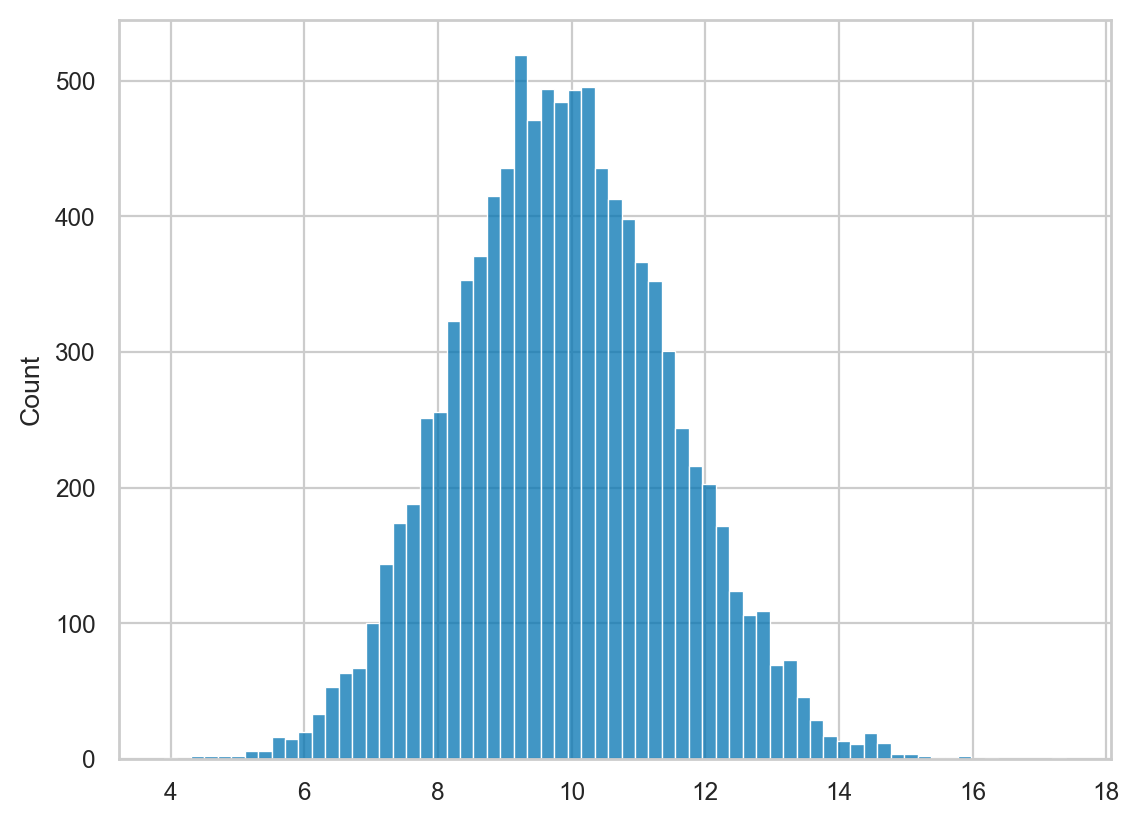

In [20]:
import seaborn as sns
# Plot histogram of the sampling distribution `kstds20`
sns.histplot(kstds20);

### E3.5

<!-- {exercise:samp-dist-of-mean-rvK-n10-30-100} -->

Generate the sampling distributions of the estimator `mean`
for samples of size $n=10$, $n=30$, and $n=100$
from the kombucha population $K \sim \mathcal{N}(1000,10)$.
Plot a histogram for each distribution
and compute its standard deviation.

In [21]:
# Create a computer model for the kombucha population
from scipy.stats import norm
muK = 1000
sigmaK = 10
rvK = norm(muK, sigmaK)

In [23]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(43)

# Simulations of `xbars` for different sample sizes
xbars10 = gen_sampling_dist(rvK, estfunc=np.mean, n=10)
xbars30 = gen_sampling_dist(rvK, estfunc=np.mean, n=30)
xbars100 = gen_sampling_dist(rvK, estfunc=np.mean, n=100)

3.1344252181165833

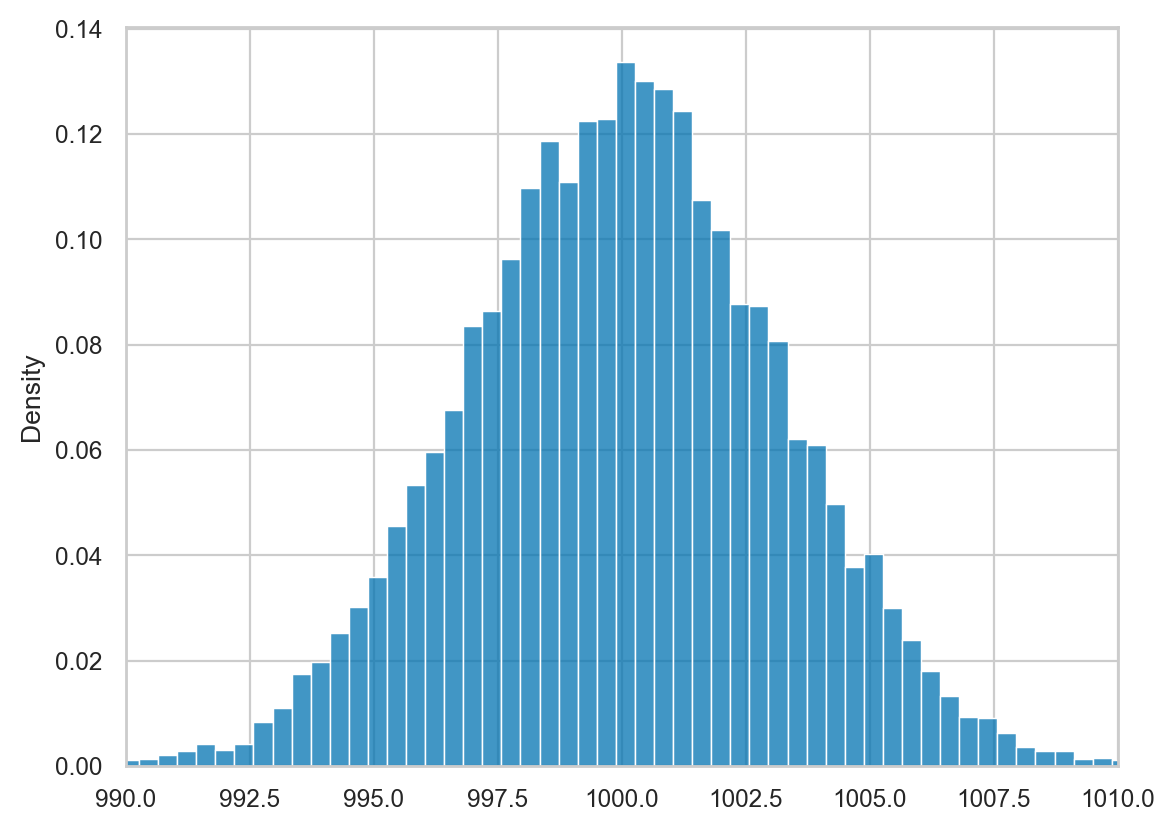

In [25]:
# Plot the histogram obtained from the n = 10 simulation
ax = sns.histplot(xbars10, stat="density")
ax.set_xlim([990,1010])

# Compute the standard deviation of the sampling distribution
np.std(xbars10)

1.8051604416489098

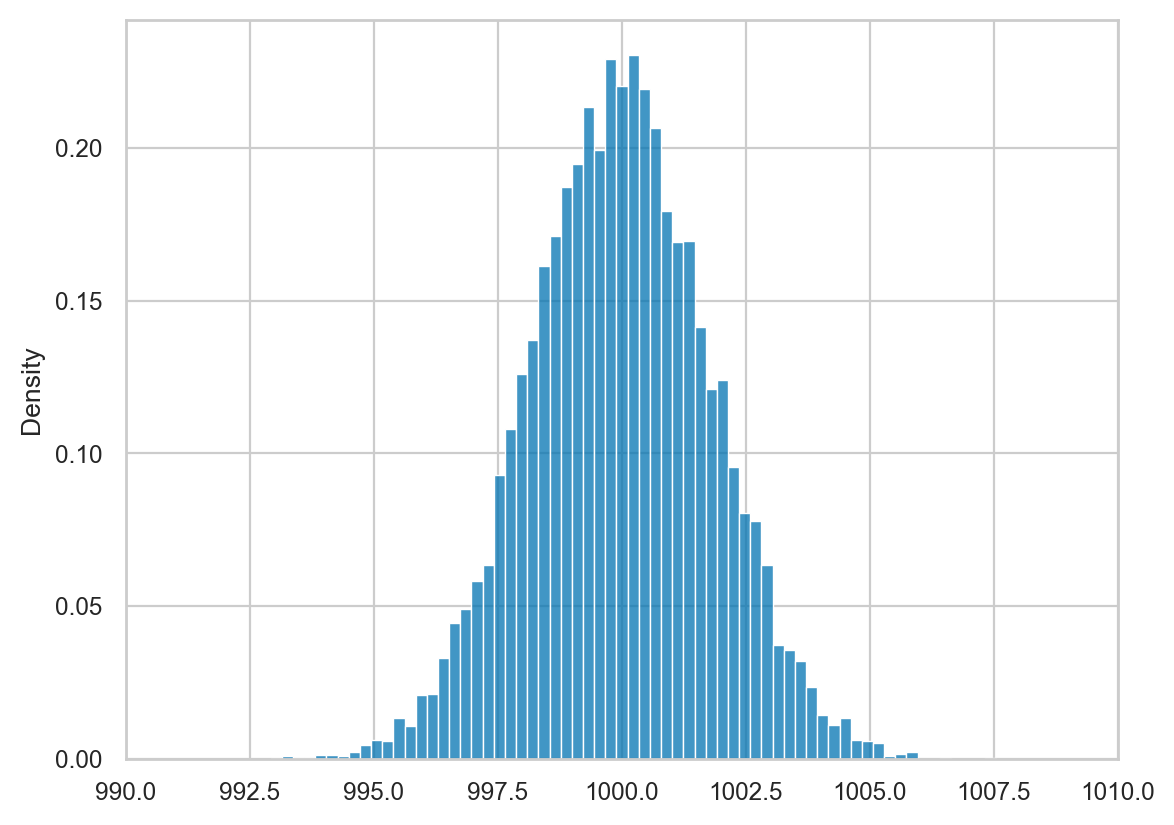

In [27]:
# Plot the histogram obtained from the n = 30 simulation
ax = sns.histplot(xbars30, stat="density")
ax.set_xlim([990,1010])

# Compute the standard deviation of the sampling distribution
np.std(xbars30)

0.9982856344634795

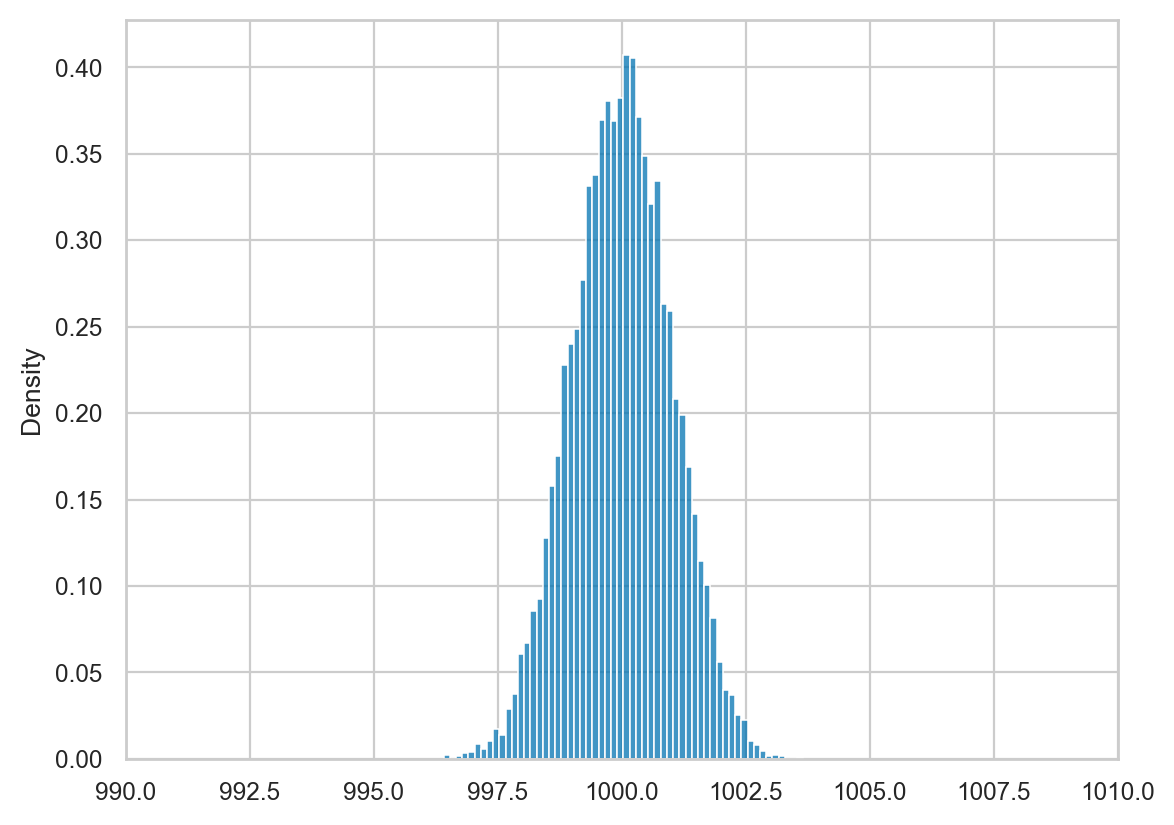

In [29]:
# Plot the histogram obtained from the n = 100 simulation
ax = sns.histplot(xbars100, stat="density")
ax.set_xlim([990,1010])

# Compute the standard deviation of the sampling distribution
np.std(xbars100)

### E3.6

<!-- {exercise:samp-dist-of-mean-rvU-n30} -->

Simulate the sampling distribution of the mean for samples of size $n=30$
from the standard uniform distribution $U \sim \mathcal{U}(0,1)$.
Plot a histogram and calculate the standard error $\stderr{\overline{\mathbf{u}}}$.

In [30]:
# Create a computer model for the standard uniform
from scipy.stats import uniform
rvU = uniform(0,1)

0.053696970885011554

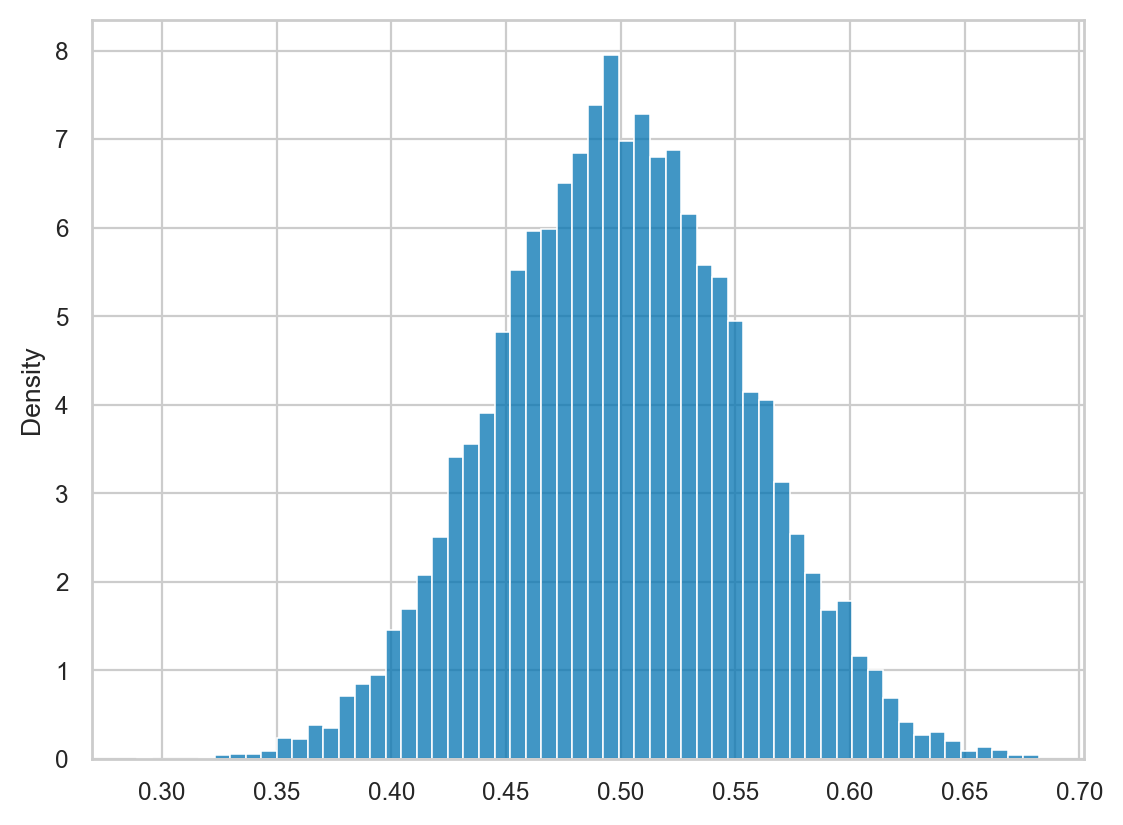

In [32]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(44)

# Simulate sampling distribution for samples of size n = 30
ubars30 = gen_sampling_dist(rvU, estfunc=np.mean, n=30)

# Plot the histogram obtained from simulation
sns.histplot(ubars30, stat="density")

# Compute the standard error (standard deviation of the sampling distribution)
np.std(ubars30)

## Exercises 3

### E3.7

<!-- {exercise:samp-dist-apples-mean-via-bootstrap} -->

Use the apples dataset
[`datasets/apples.csv`](https://noBSstats.com/datasets/apples.csv)
and bootstrap estimation
to approximate the sampling distribution of the mean for samples of size $n=30$ from the apples population
and calculate the bootstrap standard error $\stderrhat{\overline{\mathbf{a}}}^*$.
Based on your result,
describe the accuracy of the estimate $\overline{\mathbf{a}} = 202.6$
for the population mean $\mu_A$.


Hint: Use `gen_boot_dist` to generate the bootstrap distribution.

In [33]:
# Load the apples dataset
apples = pd.read_csv("datasets/apples.csv")
asample = apples["weight"]

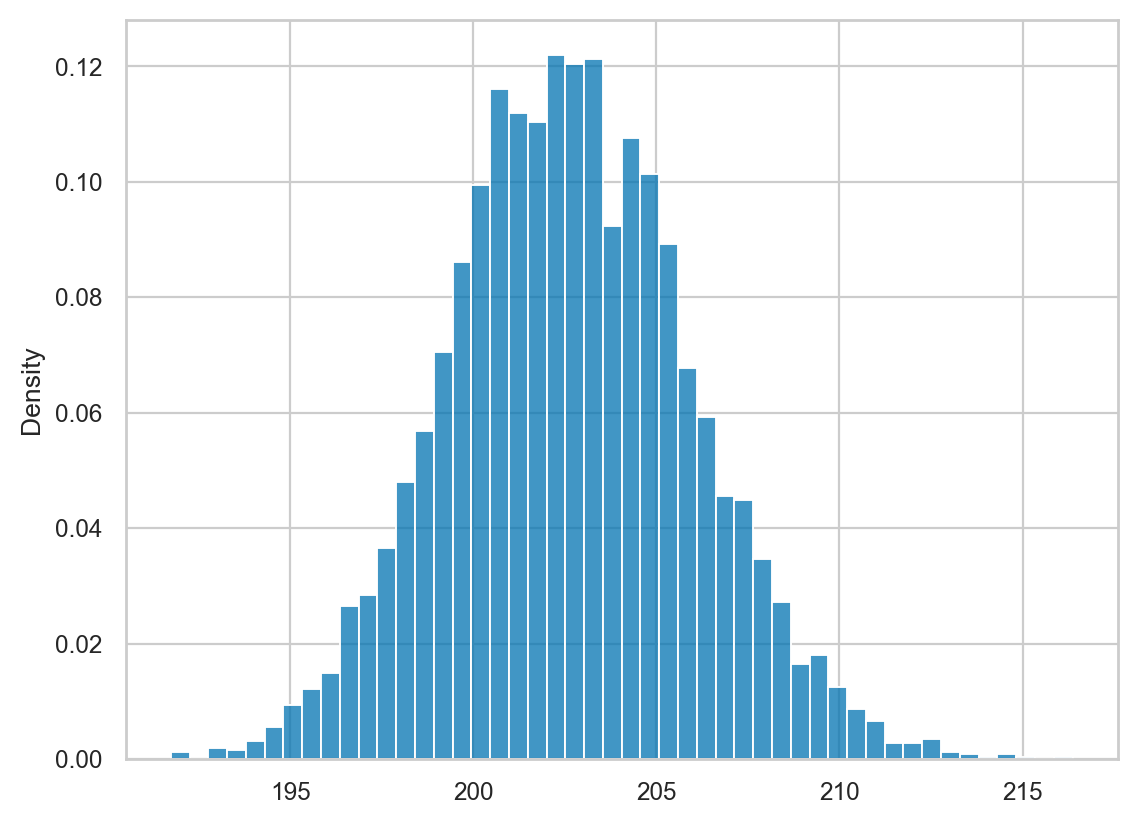

In [35]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(46)

# Generate the bootstrap distribution of the mean
from ministats import gen_boot_dist
abars_boot = gen_boot_dist(asample, estfunc=np.mean)

# Plot a histogram of the bootstrap distribution
sns.histplot(abars_boot, stat="density");

In [37]:
# Compute the standard deviation of `abars_boot`
np.std(abars_boot)

3.3281116130856487

The standard error $\stderrhat{\overline{\mathbf{a}}}^* = 3.33$
gives us an indication of the accuracy of the estimate
for the population mean $\overline{\mathbf{a}} \approx \mu_A$.
We can write our estimate plus or minus the \emph{margin of error}
$\overline{\mathbf{a}} \pm \stderrhat{\overline{\mathbf{a}}}^* = 202.6 \pm 3.33$.

### E3.8

<!-- {exercise:samp-dist-batch-04-via-bootstrap} -->

Generate the bootstrap distribution for the mean
from Batch 04 of the kombucha dataset
and compute its standard error $\stderrhat{\overline{\mathbf{k}}_{04}}^*$.
Plot a histogram of the bootstrap distribution.
Based on the observed sample mean $\overline{\mathbf{k}}_{04}$,
the bootstrap standard error $\stderrhat{\overline{\mathbf{k}}_{04}}^*$,
and the histogram,
do you think Batch 04 is a regular production batch?


Hint: Recall that regular kombucha batches have $\mu_K = 1000$.

In [38]:
# Select Batch 04 from the kombucha dataset
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample04 = kombucha[kombucha["batch"]==4]["volume"]
ksample04.mean()

1003.8335

The mean of computed from the sample 04 is $\overline{\mathbf{x}}_{04} = 1003.8335$,
which is higher than expected from a regular batch ($\mu_K = 1000$).

In [40]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(47)

# Generate the bootstrap distribution of the mean
from ministats import gen_boot_dist
kbars04_boot = gen_boot_dist(ksample04, estfunc=np.mean)

# Compute the standard deviation of `kbars04_boot`
np.std(kbars04_boot)

1.2364488755043346

In [41]:
# How far is the sample mean from the expected mean mu_K = 1000 ?
(ksample04.mean() - 1000) / np.std(kbars04_boot)

3.100411247037055

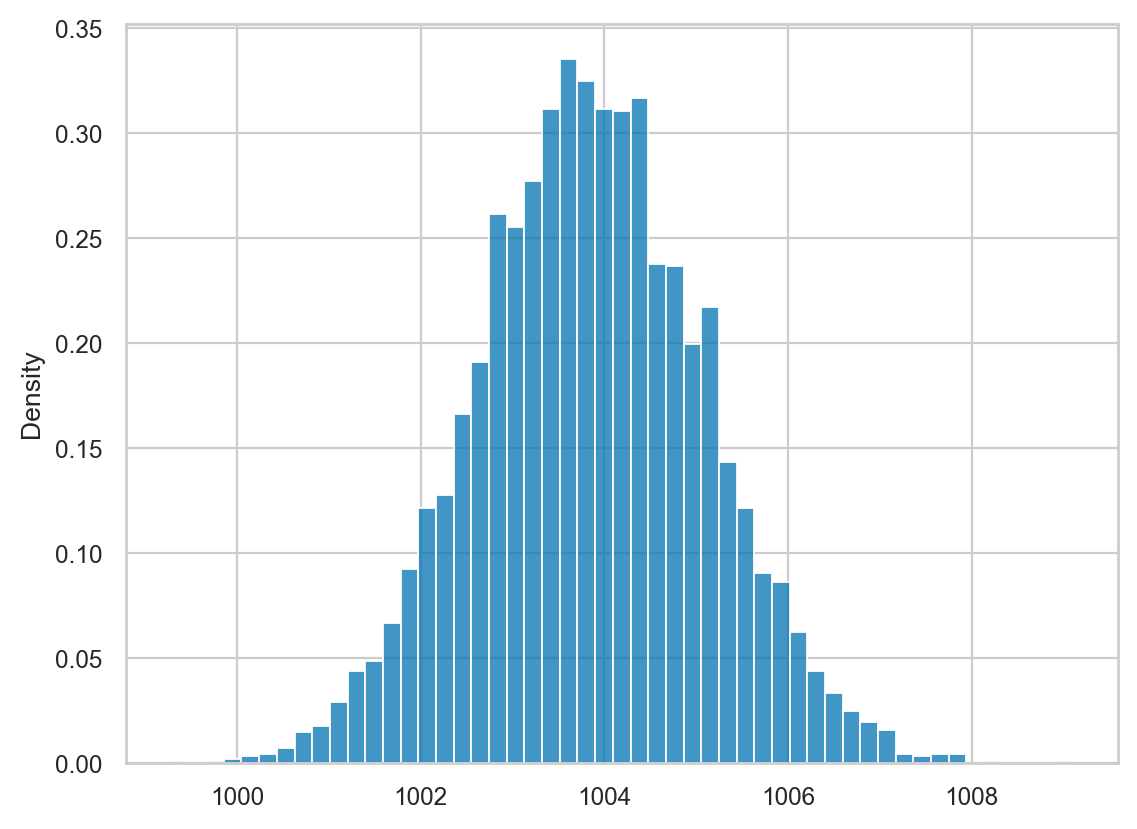

In [42]:
# Plot a histogram of the bootstrap distribution
sns.histplot(kbars04_boot, stat="density");

When we take into account of the possible variability
in the estimate $\overline{\mathbf{k}}_{04} = 1003.8$,
we see that it is very far from the expected mean $\mu_K = 1000$.
This means the Batch 04 is likely not regular batch:
the volume in this batch is higher than expected for regular batches $\mu_K = 1000$.

## Exercises 4

### E3.9

<!-- {exercise:uncertainty-apples-mean-different-ways} -->

Describe the uncertainty about the unknown population mean $\mu_A$
based on the sample of apple weights $\mathbf{a}$
from the [apples dataset](https://noBSstats.com/datasets/apples.csv).

**a)** Describe the uncertainty about $\mu_A$
by generating the bootstrap distribution from the sample $\mathbf{a}$.

**b)** Describe the uncertainty using Student's $t$-distribution
centred at $\overline{\mathbf{a}}$,
with scale $\stderrhat{\overline{\mathbf{a}}} = \frac{s_{\mathbf{a}}}{\sqrt{n}}$,
and $\nu = n -1$ degrees of freedom.

**c)** Compare your answers from part **a)** and **b)** graphically.


In [43]:
# Load the apples dataset
apples = pd.read_csv("datasets/apples.csv")
asample = apples["weight"]

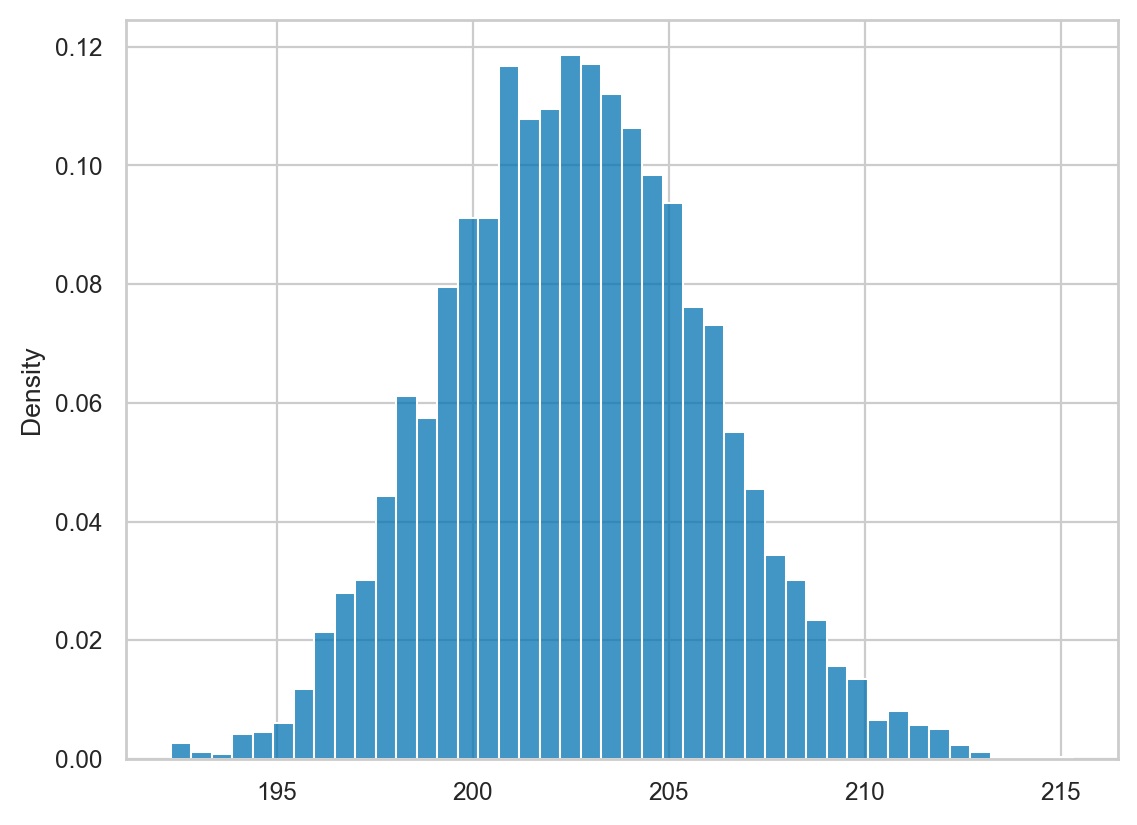

In [45]:
# a)
# Set the random seed to a particular value to get a reproducible result
np.random.seed(50)

# Obtain the bootstrap distribution of the mean
from ministats import gen_boot_dist
abars_boot = gen_boot_dist(asample, estfunc=np.mean)

# Plot a histogram of the bootstrap distribution
sns.histplot(abars_boot, stat="density");

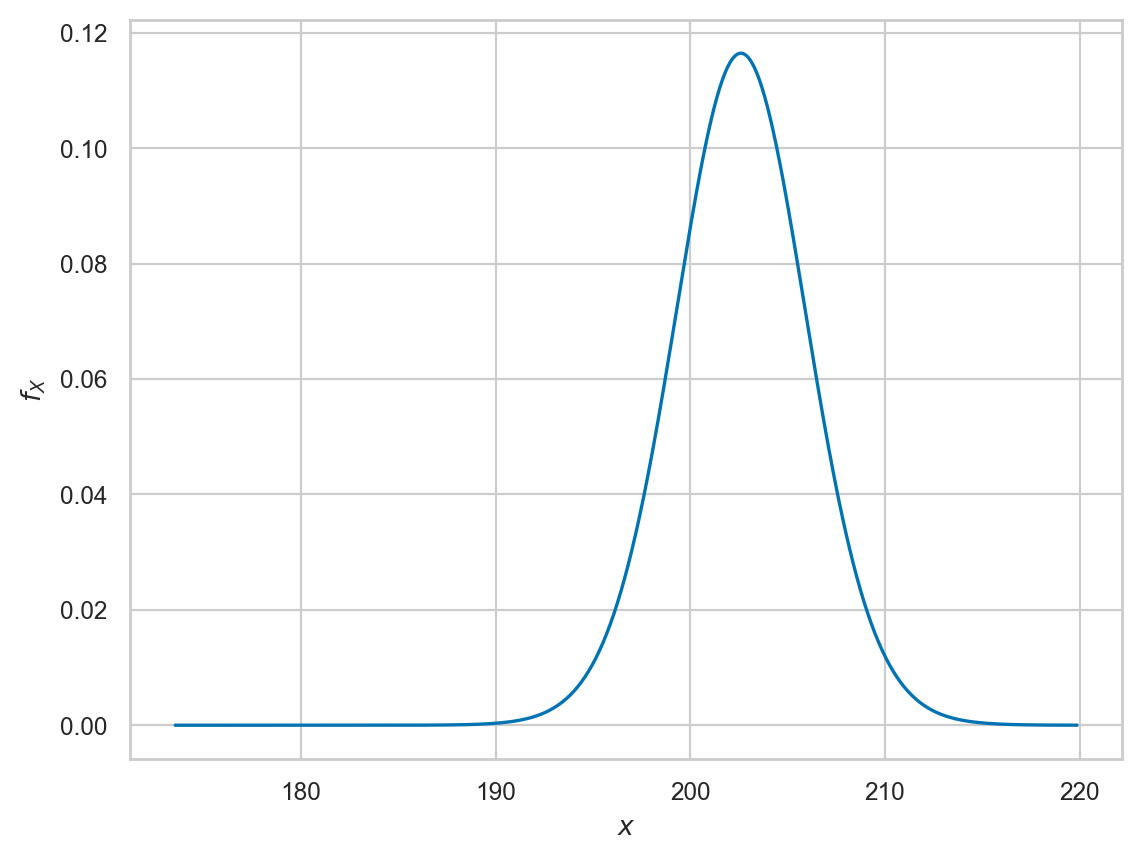

In [47]:
# b) 
# Calculate the estimated standard error
n = len(asample)
sehatAbar = asample.std() / np.sqrt(n)

# Build a model for the uncertainty in the population mean
from scipy.stats import t as tdist
df = n-1
loc = asample.mean()
scale = sehatAbar
rvTAbar = tdist(df, loc=loc, scale=scale)

# Plot the PDF of the model `rvTAbar`
from ministats import plot_pdf
ax = plot_pdf(rvTAbar)

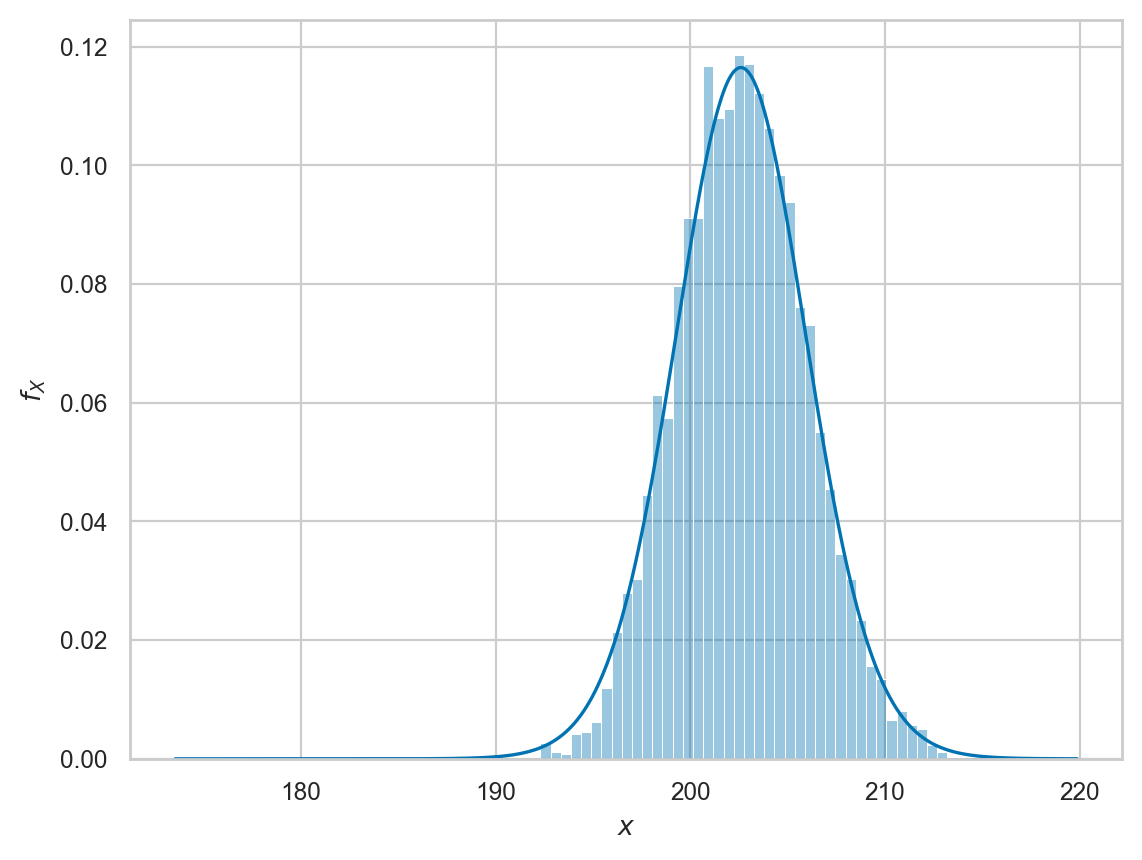

In [49]:
# c) Plot of the PDF of the analytical model
#    and the bootstrap distribution on the same axis
ax = plot_pdf(rvTAbar)
sns.histplot(abars_boot, stat="density", ax=ax, alpha=0.4);

## Exercises 5

### E3.10

<!-- {exercise:samp-dist-var-rvK-n40} -->

Under regular operations,
the kombucha volume population
is described by the model $K \sim \mathcal{N}(\mu_K\!=\!1000, \sigma_K\!=\!10)$.

**a)** Construct an analytical model for the sampling distribution of the variance
for samples of size $n=40$ from $K$.

**b)** Compute the sample variance $s_{\mathbf{k}_{08}}^2$ of the kombucha Batch 08.

**c)** Compare the observed value in **b)** to the sampling distribution in **a)**.
Is Batch 08 a regular batch or an irregular batch?

Hint: Build an analytical model based on the $\chi^2$ distribution.

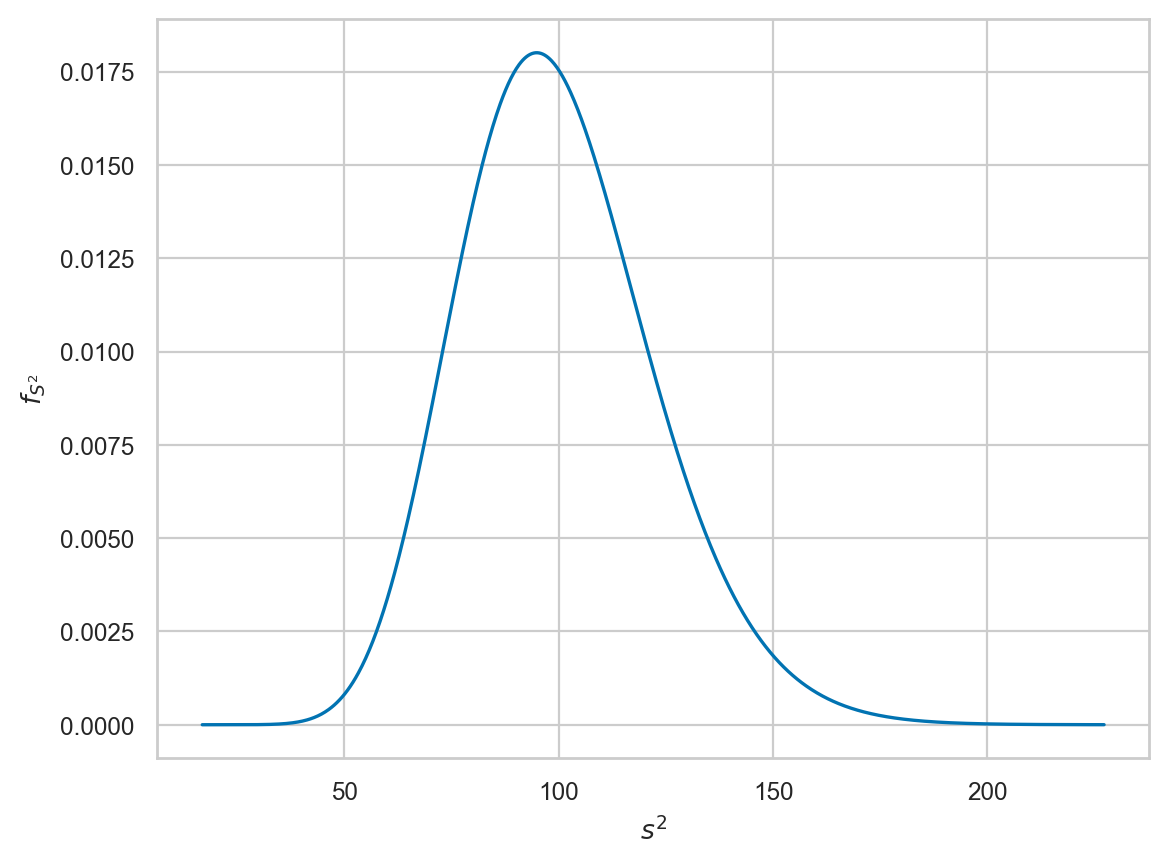

In [51]:
# a) Build an analytical model for the sampling distribution of the variance
sigmaK = 10  # population standard deviation
from scipy.stats import chi2
n = 40
df = n - 1
scale = sigmaK**2 / (n-1)
rvS2 = chi2(df, loc=0, scale=scale)

# Plot the PDF of `rvS2`
from ministats import plot_pdf
plot_pdf(rvS2, rv_name="S^2");

In [53]:
# b) Compute the sample variance of Batch 08
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = kombucha[kombucha["batch"]==8]["volume"]
ksample08.var()

169.99792205128236

**c)**
The observed value $s_{\mathbf{k}_{08}}^2 = 170$
is very unlikely to occur according to the sampling distribution
for regular batches.
This suggests that Batch 08 is an irregular batch
(abnormally high variance).
Better check the bottling machines!

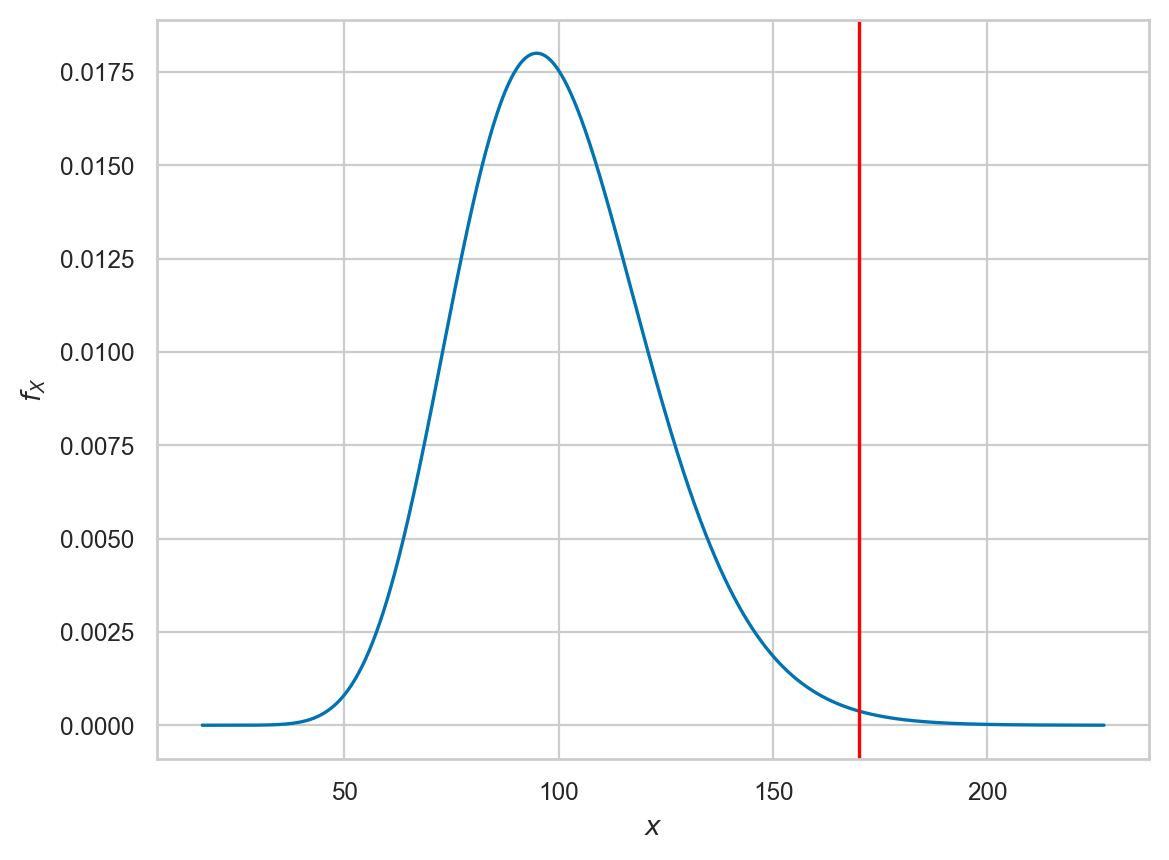

In [54]:
# Plot a vertical line at the observed variance
ax = plot_pdf(rvS2)
ax.axvline(ksample08.var(), color="red");

### E3.11

<!-- {exercise:samp-dist-var-batch-08-via-bootstrap} -->

Compute the bootstrap approximation for the sampling distribution of the variance
from the kombucha Batch 08.
Plot a histogram.
The expected variance for samples taken from a regular batch
is $\sigma_K^2 = 100$,
since the population for regular batches is $K \sim \mathcal{N}(\mu_K\!=\!1000, \sigma_K\!=\!10)$.
Is the expected variance $\sigma_K^2 = 100$
likely or unlikely according to the bootstrap distribution?

In [55]:
# Define the variance estimator function
def var(sample):
    xbar = sum(sample) / len(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return sumsqdevs / (len(sample)-1)

In [56]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = kombucha[kombucha["batch"]==8]["volume"]

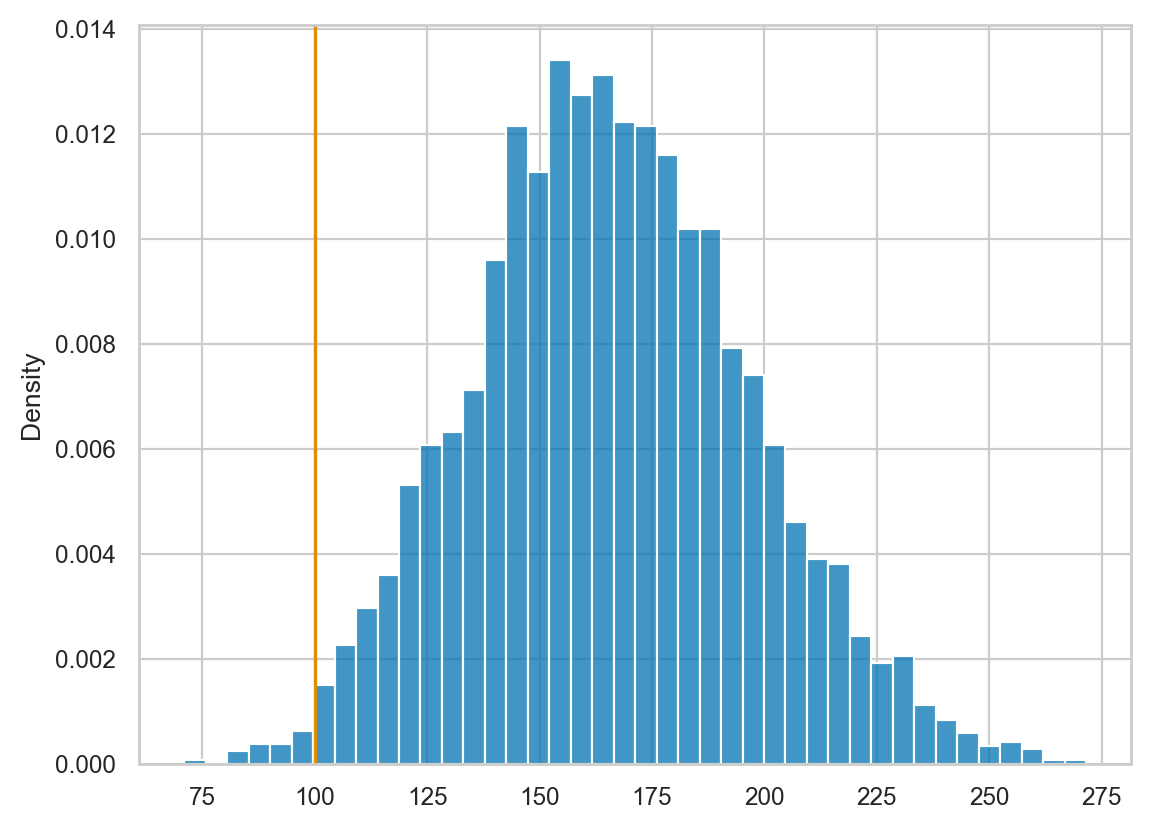

In [58]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(54)

# Generate the bootstrap distribution of the variance
from ministats import gen_boot_dist
kvars08_boot = gen_boot_dist(ksample08, estfunc=var, B=5000)

# Plot a histogram of the bootstrap distribution `kvars08_boot`
ax = sns.histplot(kvars08_boot, stat="density")

# Plot a vertical line at the expected variance
ax.axvline(100, color="C1");

The bootstrap distribution computed from $\mathbf{k}_{08}$
is centred near $s_{\mathbf{k}_{08}}^2 = 170$.
The expected variance for regular batches $\sigma_K^2 = 100$
is very unlikely under the bootstrap distribution,
which tells us Batch 08 might be irregular.

## Exercises 6

### E3.12

<!-- {exercise:samp-dist-dmeans-sleep-scores} -->

In an earlier exercise,
we calculated the difference between mean sleep scores
for doctors working in rural and urban locations: $\hat{d} = 7$.
In this exercise,
we want to describe the uncertainty in this estimate.

**a)** Obtain an approximation to the sampling distribution
of the difference between means
in terms of Student's $t$-distribution
centred at $\hat{d}$,
with scale $\stderrhat{\hat{d}}$,
and $\nu_d$ degrees of freedom.

**b)** Approximate the sampling distribution using the bootstrap.

**c)** Compare your answers from part **a)** and **b)** graphically.

In [59]:
# Load the doctors dataset and get the "rur" and "urb" scores
doctors = pd.read_csv("datasets/doctors.csv")
scoresR = doctors[doctors["loc"]=="rur"]["score"]
scoresU = doctors[doctors["loc"]=="urb"]["score"]

# observed value
dscores = scoresR.mean() - scoresU.mean()
dscores

6.992885375494076

Estimated standard error 3.5671565854251948


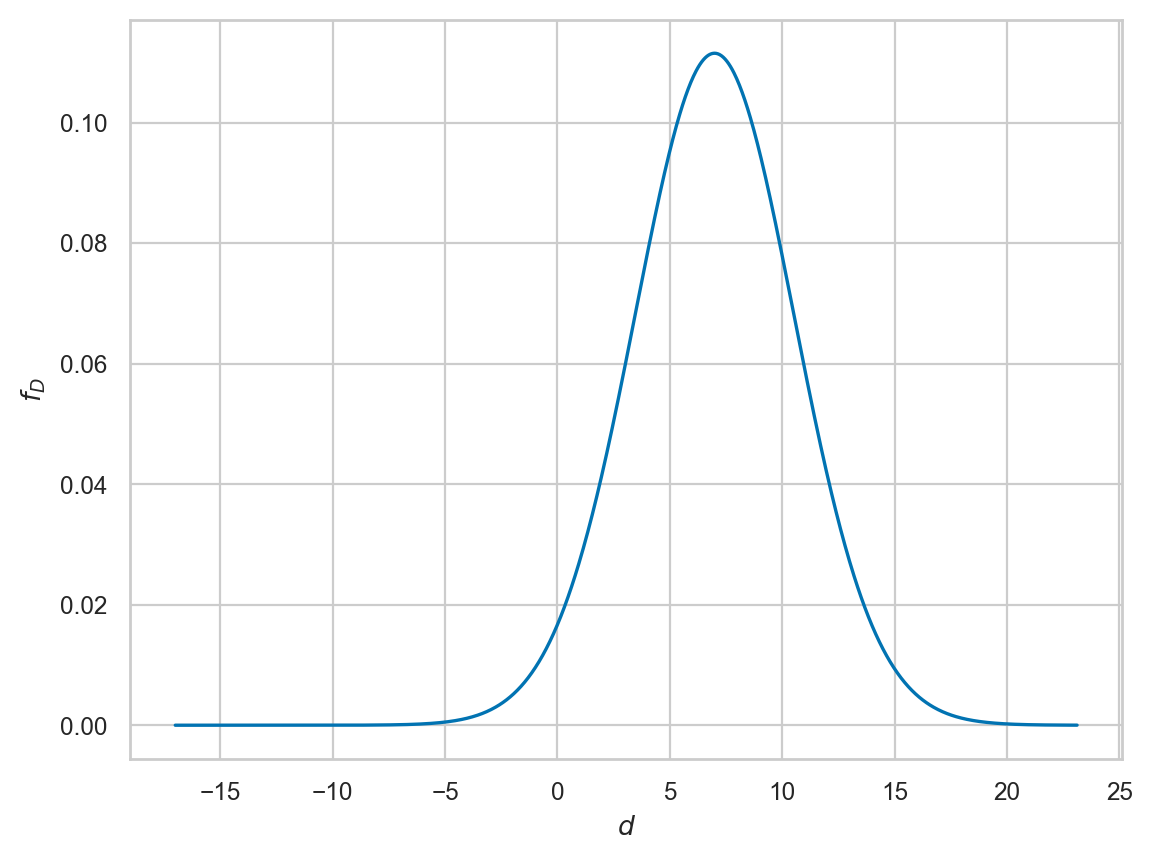

In [61]:
# a) Analytical approximation

# Obtain the sample sizes and stds for the two groups
nR = len(scoresR)
stdR = scoresR.std()
nU = len(scoresU)
stdU = scoresU.std()

# Compute the standard error of the difference between means
seDhatscores = np.sqrt(stdU**2/nU + stdR**2/nR)
print("Estimated standard error", seDhatscores)

# Calculate the degrees of freedom parameter
from ministats import calcdf
df = calcdf(stdU, nU, stdR, nR)

# Build a probability model based on Student's t-distribution
from scipy.stats import t as tdist
rvDscores = tdist(df, loc=dscores, scale=seDhatscores)

# Plot the PDF of the sampling distribution `rvDscores`
from ministats import plot_pdf
plot_pdf(rvDscores, rv_name="D");

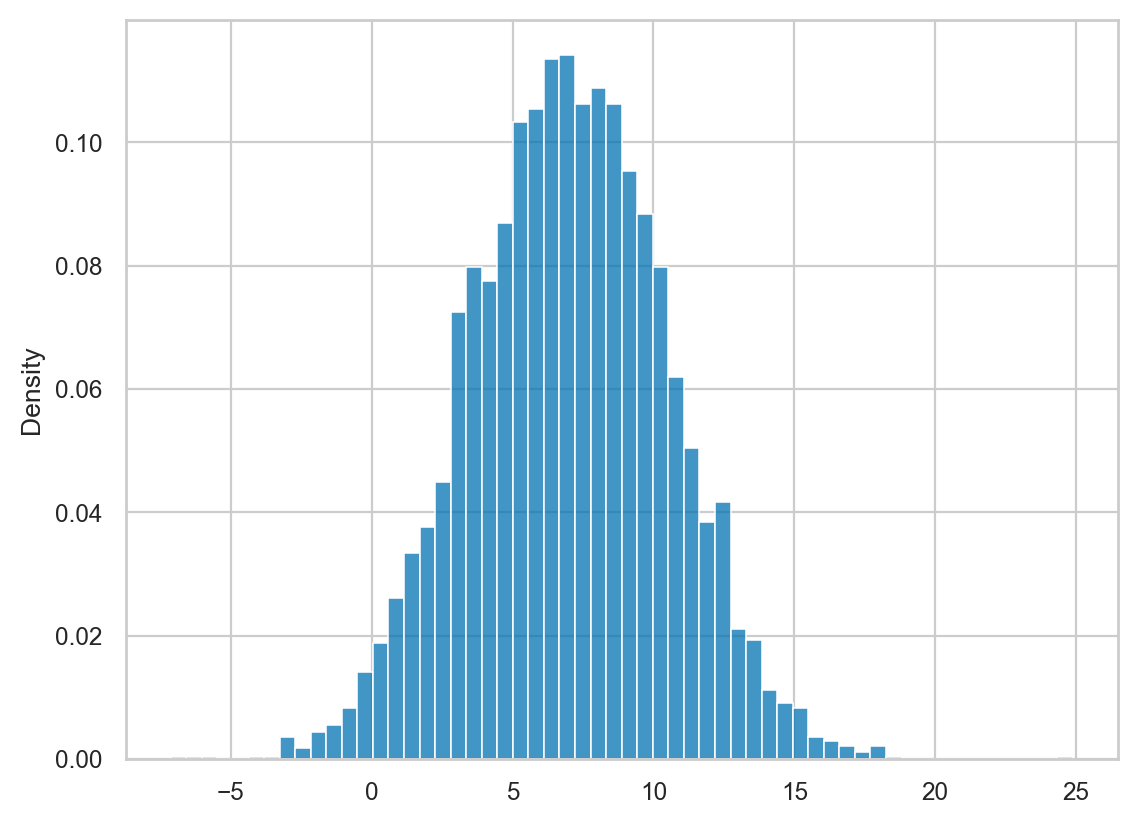

In [63]:
# b) Bootstrap estimate
# Set the random seed to a particular value to get a reproducible result
np.random.seed(51)

# Compute bootstrap estimates for mean in each group
from ministats import gen_boot_dist
meanR_boot = gen_boot_dist(scoresR, estfunc=np.mean)
meanU_boot = gen_boot_dist(scoresU, estfunc=np.mean)

# Compute the difference between means of the bootstrap samples
dmeans_boot = np.subtract(meanR_boot, meanU_boot)

# Plot a histogram of the bootstrap distribution
sns.histplot(dmeans_boot, stat="density");

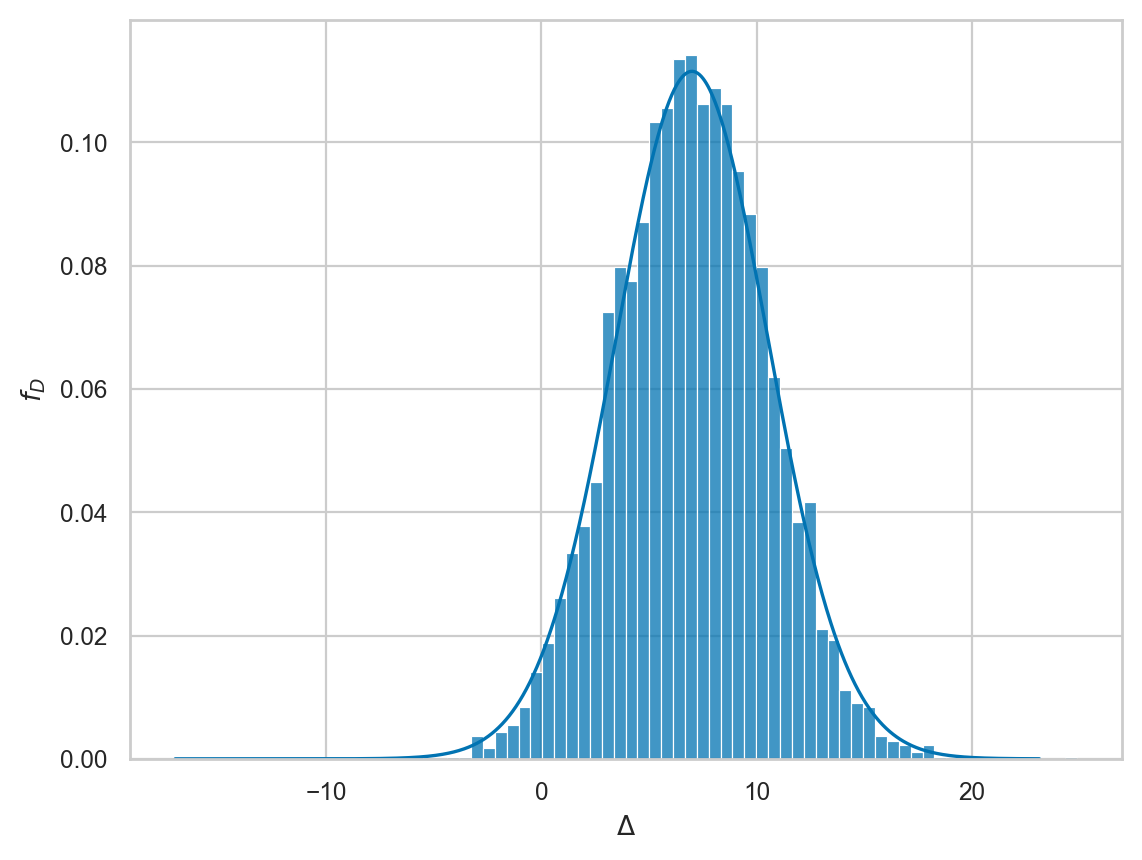

In [65]:
# c) Plot of the PDF of the analytical model
#    and the bootstrap distribution on the same axis
ax = plot_pdf(rvDscores, rv_name="D")
sns.histplot(dmeans_boot, ax=ax, stat="density")
ax.set_xlabel(r"$\Delta$");

We see the two models for the uncertainty about $\Delta = \mu_R - \mu_U$ are very similar.

## Exercises 7

### E3.13

<!-- {exercise:samp-dist-median-rvK-n30} -->

Generate the sampling distribution of the median for samples of size $n=30$
from the population $K \sim \mathcal{N}(1000,10)$.
Compute the standard error of the sampling distribution of the median.

Hint: You can use `np.median` as the estimator function.

In [66]:
# Create a computer model for the kombucha population
from scipy.stats import norm
rvK = norm(1000, 10)

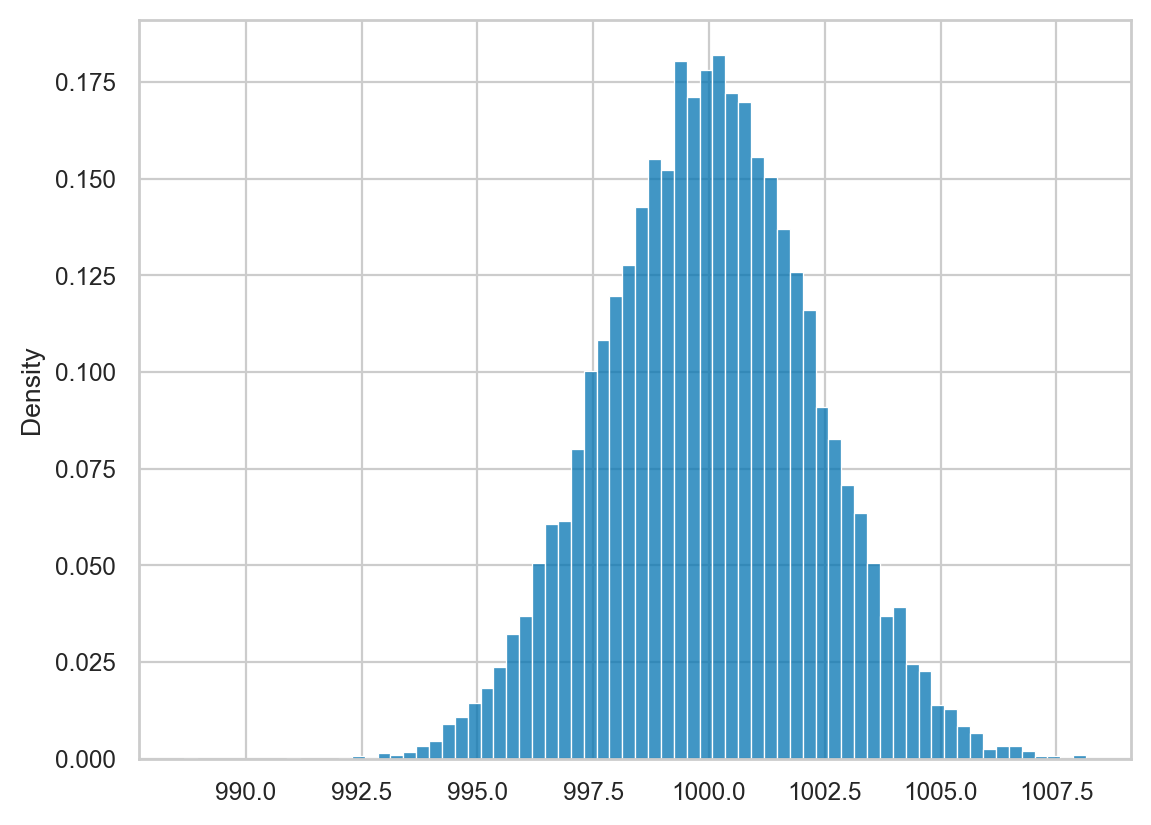

In [68]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(52)

# Compute the sampling distribution of the median (`np.median`)
# for samples of size n=30 from `rvK`
from ministats import gen_sampling_dist
kmedians30 = gen_sampling_dist(rvK, estfunc=np.median, n=30)

# Plot a histogram of the sampling distribution
sns.histplot(kmedians30, stat="density");

In [70]:
# Compute the standard error of the sampling distribution of the median
np.std(kmedians30)

2.2446814804658617

### E3.14

<!-- {exercise:samp-dist-p90-rvK-n30} -->

Generate the sampling distribution of `p90`,
the 90th percentile estimator,
from samples of size $n=30$ from $K \sim \mathcal{N}(1000,10)$.
Calculate the standard error $\stderr{\texttt{p90}}$ of the `p90` estimator.

Hint: Use $\texttt{np.percentile(}\mathbf{k}\texttt{,90)}$
to compute the 90th percentile of $\mathbf{k}$.

In [71]:
# Create a computer model for the kombucha population
from scipy.stats import norm
rvK = norm(1000, 10)

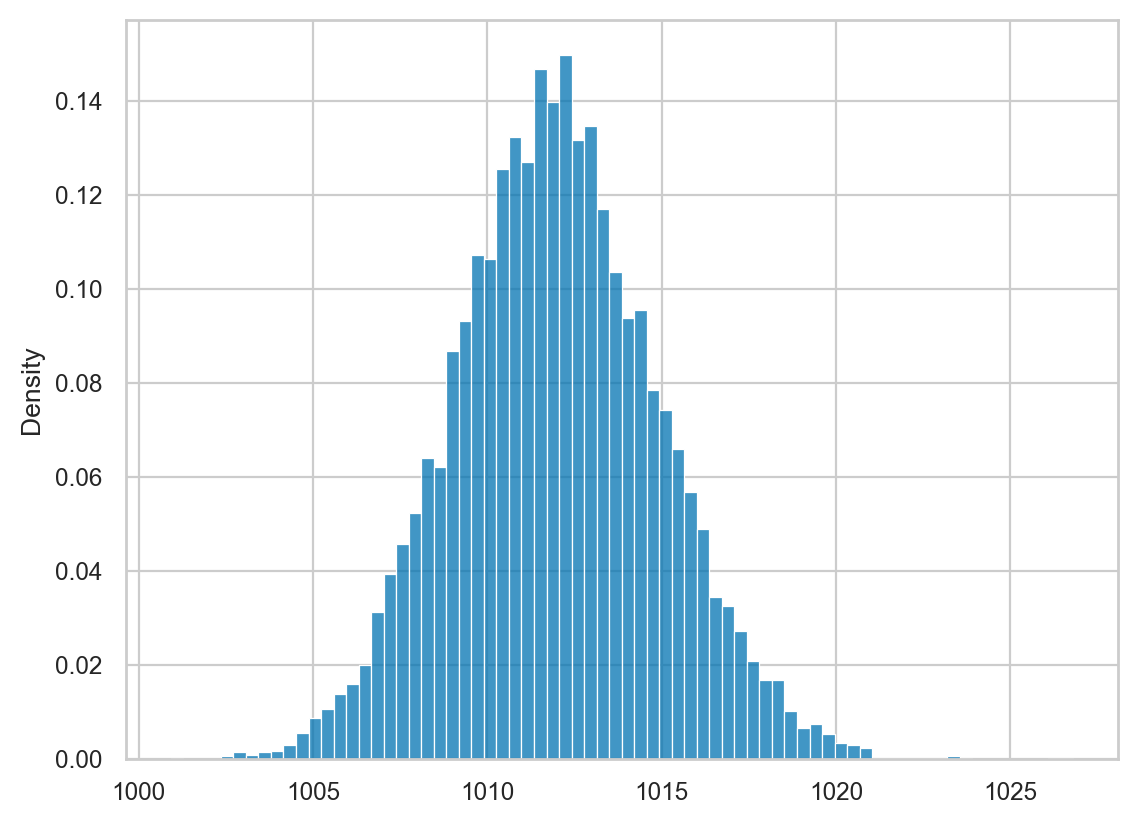

In [73]:
# Define the 90th percentile estimator function
def p90(sample):
    return np.percentile(sample, 90)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(47)

# Generate the sampling distribution of the `p90`
# for samples of size n=30 from the kombucha population
kp90s30 = gen_sampling_dist(rvK, estfunc=p90, n=30)

# Plot a histogram of the sampling distribution
sns.histplot(kp90s30, stat="density");

In [75]:
# Compute the standard error of the p90 sampling distribution
np.std(kp90s30)

2.917424577907705

### E3.15

<!-- {exercise:samp-dist-concepts-in-your-own-words} -->

For each of these concepts,
explain in your own words what it is and what it is used for:
**a)** *estimate*,
**b)** *estimator*,
**c)** *sampling distribution* of the estimator,
**d)** *standard error* of the sampling distribution.

The *estimate* $\hat{\theta}$ computed from the sample $\mathbf{x}$ is our "best guess"
about the unknown population parameter $\theta$.
We can use the estimate $\hat{\theta}$ as a substitute for $\theta$
in statistics formulas (the plug-in principle).

The *estimator* is the function $g:\mathcal{X}^n \to \mathbb{R}$
that we use to compute the estimate $\hat{\theta}$
from the sample $\mathbf{x}$ of size $n$.

The sampling distribution of the estimator $g$ for samples of size $n$
from the population $X \sim \mathcal{M}(\theta)$
is the output of the estimator function
when the input is an i.i.d random sample $\mathbf{X} = (X_1,X_2,\ldots,X_n)$,
which we can write as $\widehat{\Theta} = g(\mathbf{X})$.
The *sampling distribution* $\widehat{\Theta}$
tells us the variability in the $\hat{\theta}$-estimates
we might expect to observe from random samples of size $n$.
We use the information from the sampling distribution
to describe the uncertainty about the estimates we obtain from a particular sample.

The *standard error* of the estimator $g$,
denoted $\stderr{g}$ or $\stderr{\hat{\theta}}$,
is the standard deviation of the sampling distribution $\widehat{\Theta}$.
The standard error
quantifies the accuracy of the approximation $\hat{\theta} \approx \theta$.
It tells us how "far apart"
we can expect the estimates $\hat{\theta}$ computed from a sample $\mathbf{x}$
to be from the true population parameter $\theta$,
measured in "standard" units.
In Type P tasks,
the population parameter $\theta$ is known,
and we use the standard error to judge if an observed estimate $\hat{\theta}$ has high probability (few standard errors away)
or low probability (many standard errors away).
In Type E tasks,
$\theta$ is unknown,
and we use the sampling distribution centred at $\hat{\theta} = g(\mathbf{x})$
to judge the *likelihood* that the sample $\mathbf{x}$
came from a population with parameter $\theta$.
The likelihood of $\theta$s close to $\hat{\theta}$ (few standard errors away) is high;
the likelihood of $\theta$s far from $\hat{\theta}$ (many standard errors away) is low.

### E3.16

<!-- {exercise:use-scipy.stats.bootstrap} -->

Use the function `scipy.stats.bootstrap`
to compute the bootstrap distribution of the variance from Batch 08 of the kombucha dataset.
Plot a histogram of the bootstrap distribution
and compare it to the histogram of `kvars08_boot` you obtained in the earlier exercise using `gen_boot_dist`.

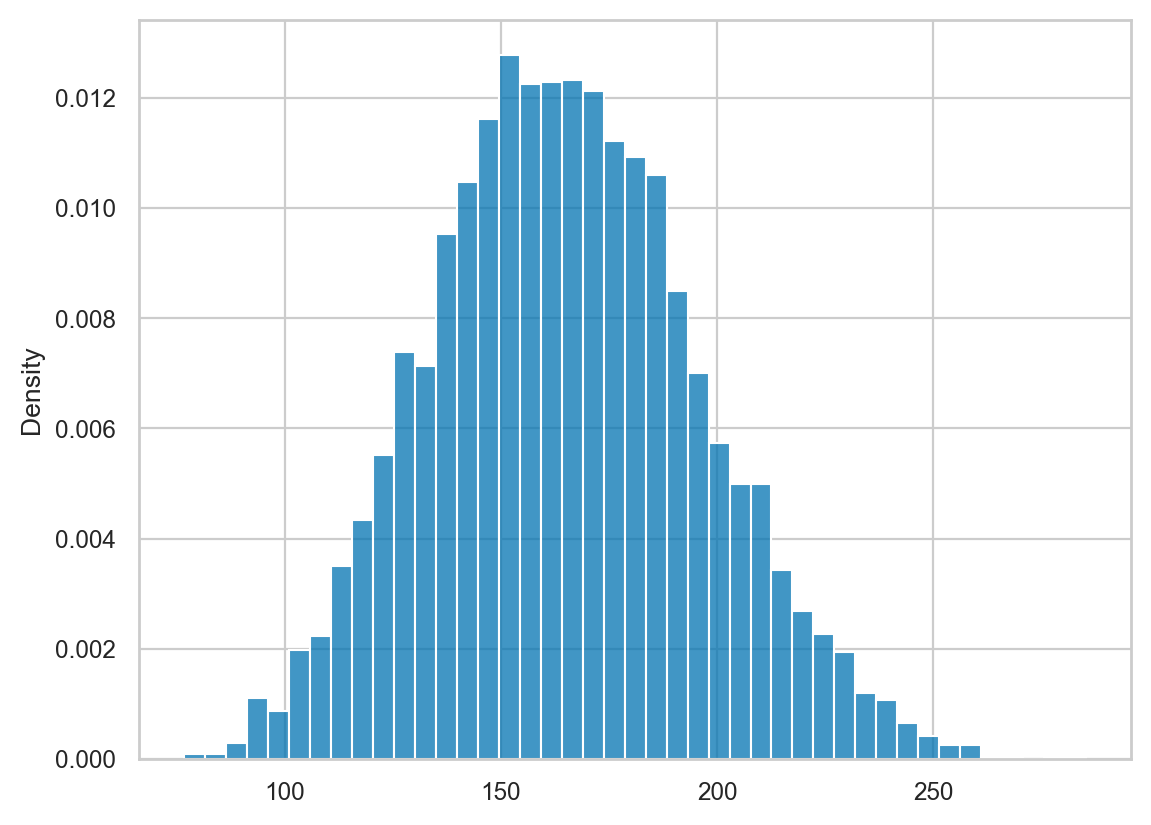

In [77]:
# Select the volume measurements from Batch 08
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample08 = kombucha[kombucha["batch"]==8]["volume"]

# Set the random seed to a particular value to get a reproducible result
np.random.seed(49)

# Call the function scipy.stats.bootstrap
from scipy.stats import bootstrap
res = bootstrap([ksample08], statistic=var,
                n_resamples=5000, vectorized=False)

# Plot a histogram of the sampling distribution
sns.histplot(res.bootstrap_distribution, stat="density");

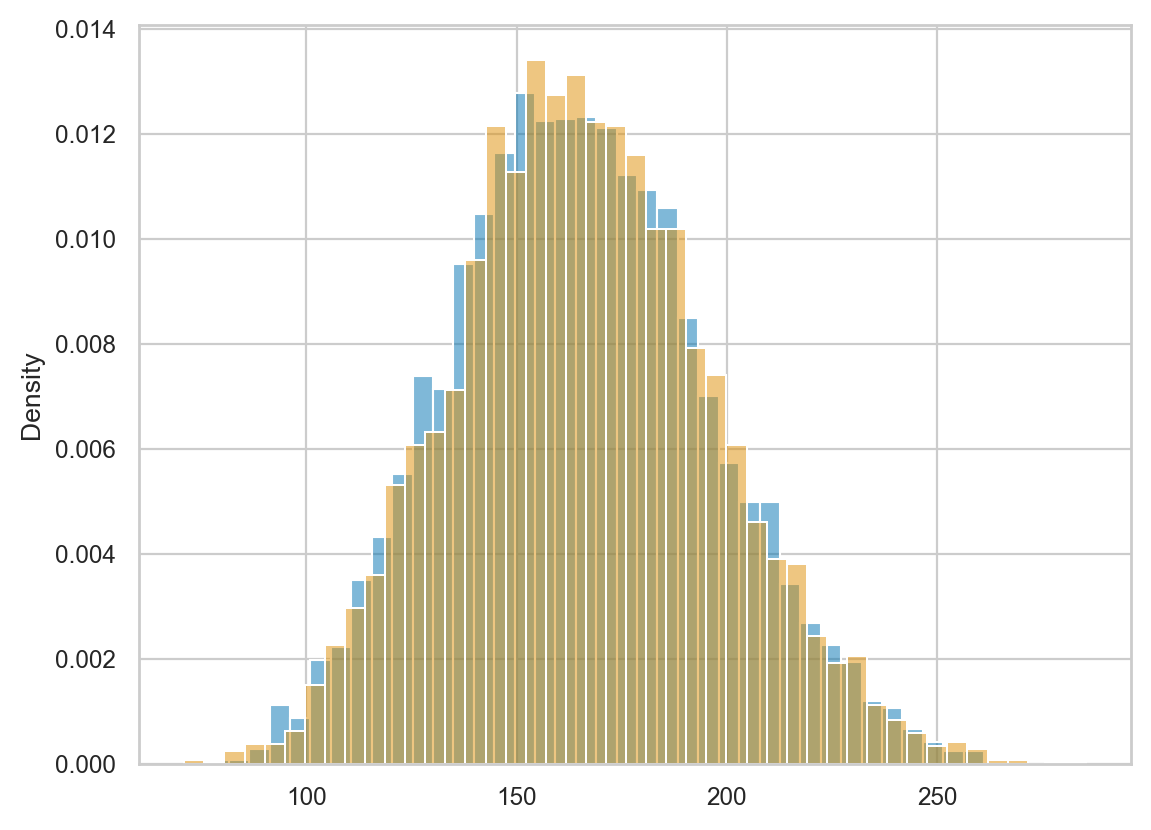

In [79]:
# Plot the bootstrap distribution obtained from scipy.stats.bootstrap
# and the bootstrap distribution `kvars08_boot` we obtained earlier.
ax = sns.histplot(res.bootstrap_distribution, stat="density", alpha=0.5)
sns.histplot(kvars08_boot, ax=ax, stat="density", color="C1", alpha=0.5);